In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


#read the data

# list files in dir
eval_rewards = {}
eval_stats = {}
for rfunc in ['v0','v1','v2']:
    rname = f'{rfunc}/rewards_{rfunc}.csv'
    sname = f'{rfunc}/coverage_{rfunc}.csv'
    rewards = pd.read_csv(os.path.join('evaluation_results', rname))
    stats = pd.read_csv(os.path.join('evaluation_results', sname))
    eval_rewards[rfunc] = rewards
    eval_stats[rfunc] = stats

train_rewards = {}
train_stats = {}
for rfunc in ['v0','v1','v2']:
    rname = f'{rfunc}/rewards_{rfunc}.csv'
    sname = f'{rfunc}/coverage_{rfunc}.csv'
    rewards = pd.read_csv(os.path.join('results', rname))
    stats = pd.read_csv(os.path.join('results', sname))
    train_rewards[rfunc] = rewards
    train_stats[rfunc] = stats




In [2]:
print(train_stats['v0'])

   Coverage
0    12.875


### Plotting train data

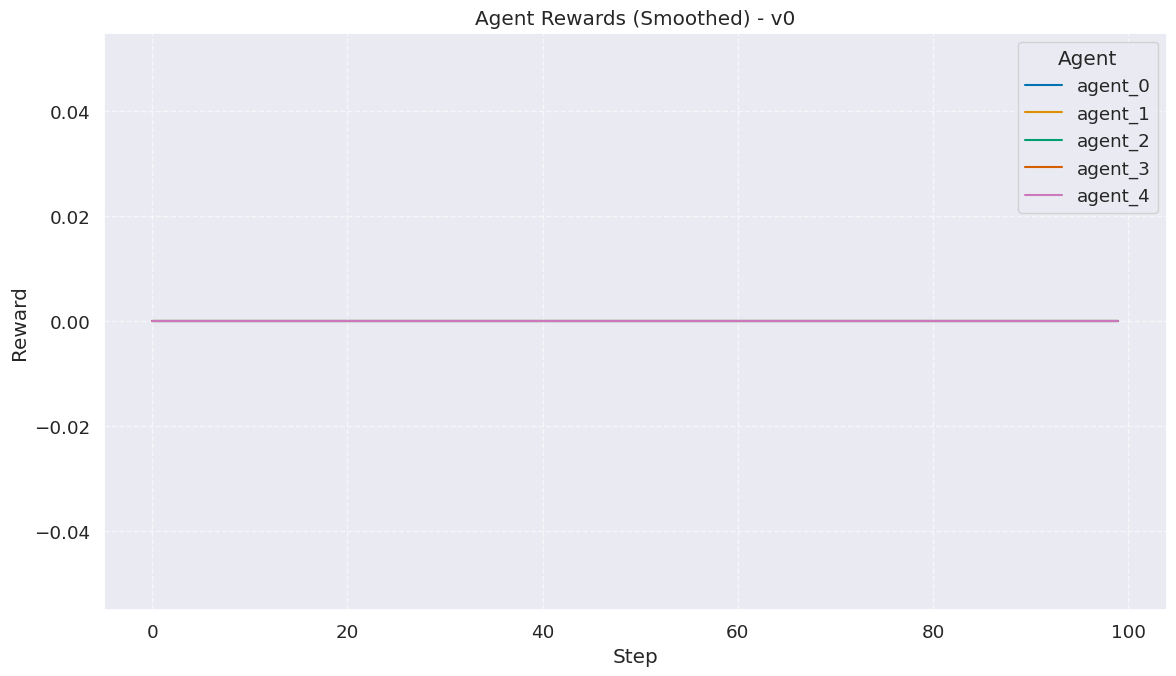

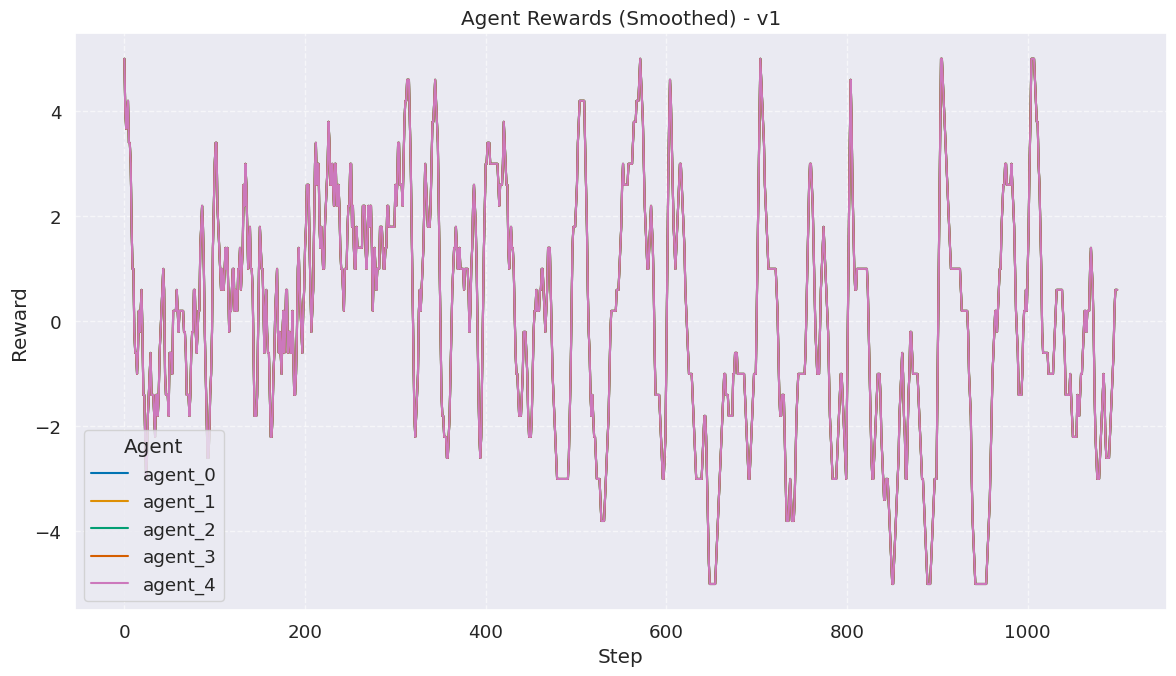

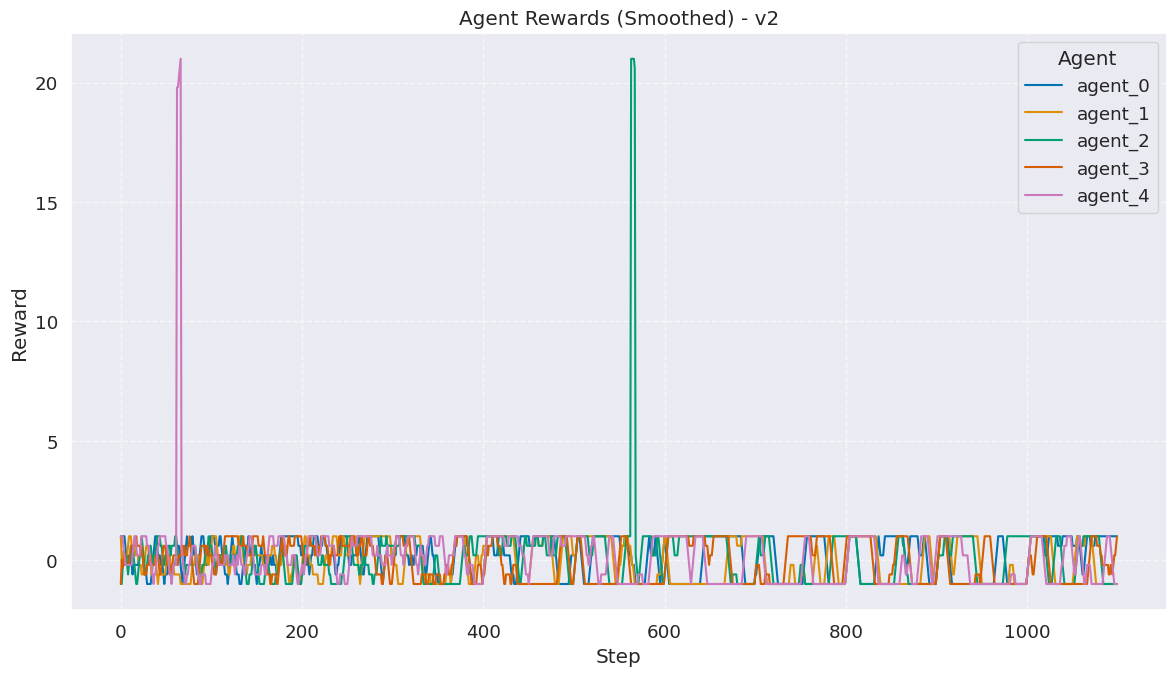

   Coverage
0    12.875
    Coverage
0    14.6875
1    15.6875
2    20.1875
3    19.5625
4    15.8750
5    17.0000
6    11.8125
7    13.6250
8    10.3750
9    15.0625
10   15.1875
    Coverage
0    16.0000
1    17.3125
2    19.3750
3    14.7500
4    20.1250
5    16.2500
6    16.8750
7    10.5000
8    13.9375
9    11.6875
10   17.1875


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set_theme(style="darkgrid", palette="colorblind", font_scale=1.2)

window_size = 5  # Rolling window size

for name in train_rewards:
    agents = train_rewards[name]

    # Apply rolling window smoothing
    smoothed = agents.rolling(window=window_size, min_periods=1).mean()

    # Prepare for plotting
    df_long = smoothed.reset_index().melt(
        id_vars='index', var_name='Agent', value_name='Value'
    )

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df_long, x='index', y='Value', hue='Agent', linewidth=1.5)

    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.title(f'Agent Rewards (Smoothed) - {name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

